In [1]:
# diamonds 부분

In [30]:
import sys

sys.path.append(r'C:\임시 폴더')

from jussam import load_data
# from helper212 import *
# from helper224 import *
# from helper230 import *
# from helper236 import *
# from helper242 import *
# from helper246 import *
from helper254 import *

In [3]:
원본 = load_data('diamonds')

원본.head()

📚 다이아몬드를 커팅, 색상, 투명도, 가격 및 기타 속성 조사한 데이터 셋 (출처: https://www.kaggle.com/datasets/shivam2503/diamonds)

    field    description
--  -------  -------------------------------------------------------------------
 0  price    다이아몬드 가격 (USD, $326 ~ $18,823)
 1  carat    중량 (0.2~5.01)
 2  cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
 3  color    색상 등급 - J (worst) to D (best)
 4  clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
 5  x        길이 mm (0~10.74)
 6  y        너비 mm (0--58.9)
 7  z        두께 mm (0--31.8)
 8  depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
 9  table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)



,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.230,Ideal,E,SI2,3.950,3.980,2.430,61.500,55.000
1,326,0.210,Premium,E,SI1,3.890,3.840,2.310,59.800,61.000
2,327,0.230,Good,E,VS1,4.050,4.070,2.310,56.900,65.000
3,334,0.290,Premium,I,VS2,4.200,4.230,2.630,62.400,58.000
4,335,0.310,Good,J,SI2,4.340,4.350,2.750,63.300,58.000


In [4]:
원본.info()

# 명확한 결측치는 없음

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   price    53940 non-null  int64  
 1   carat    53940 non-null  float64
 2   cut      53940 non-null  str    
 3   color    53940 non-null  str    
 4   clarity  53940 non-null  str    
 5   x        53940 non-null  float64
 6   y        53940 non-null  float64
 7   z        53940 non-null  float64
 8   depth    53940 non-null  float64
 9   table    53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.7 MB


In [5]:
# 관측치 행

print(f'관측치 행은 {원본.shape[0]} 개')

관측치 행은 53940 개


In [6]:
# 몇 개의 칼럼

print(f'칼럼 개수는 {원본.shape[1]} 개')

칼럼 개수는 10 개


In [7]:
df = my_EDA.결측치_중복_전처리(원본)

# 중복만 확인 후 전처리 됨
df.shape[0]

,결측치 개수,결측치 비율 (%)
price,0,0.000
carat,0,0.000
cut,0,0.000
color,0,0.000
clarity,0,0.000
x,0,0.000
y,0,0.000
z,0,0.000
depth,0,0.000
table,0,0.000


중복된 행의 수는 146
중복된 행이 제거 됨
결측치 점검 및 중복 전처리 완료됨!!



53794

In [8]:
# 명확하게 보이는 불필요한 변수는 없음

# 각각 도메인 확인
for 개별_칼럼 in df.columns :

    # 30 개 이하면 명목형일 가능성이 높다고 일단 판단하자
    if df[개별_칼럼].nunique() <= 30:
        print(f'{개별_칼럼} 의 도메인은 {df[개별_칼럼].unique()} 이다.\n')

cut 의 도메인은 <ArrowStringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str 이다.

color 의 도메인은 <ArrowStringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str 이다.

clarity 의 도메인은 <ArrowStringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str 이다.



In [9]:
# 도메인 확인 과정도 모듈화에 추가함

예상_카테고리_결과 = my_EDA.도메인_확인(원본)

display(예상_카테고리_결과)

cut 의 도메인은 <ArrowStringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str 이다.

color 의 도메인은 <ArrowStringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str 이다.

clarity 의 도메인은 <ArrowStringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str 이다.

카테고리 느낌의 칼럼은 ['cut', 'color', 'clarity'] 로 예상


['cut', 'color', 'clarity']

In [10]:
종속변수 = 'price'
카테고리_모음 = ['cut' , 'color' , 'clarity']

df1 = my_EDA.카테고리_임의_변환(df , 카테고리_모음)

<class 'pandas.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   depth    53794 non-null  float64 
 9   table    53794 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.4 MB


None

In [11]:
# 변수 구분 작업

기술통계량 , 명목형_기술통계량 , 카테고리_변환 , 명목형_변수 , 연속형_변수 = my_EDA.변수구분(대상 = df1 , 종속변수 = 종속변수)

In [12]:
명목형_기술통계량

,cut,color,clarity
count,53794,53794,53794
unique,5,7,8
top,Ideal,G,SI1
freq,21488,11262,13032


In [13]:
기술통계량.T

,price,carat,x,y,z,depth,table
count,53794.000,53794.000,53794.000,53794.000,53794.000,53794.000,53794.000
mean,3933.065,0.798,5.731,5.735,3.539,61.748,57.458
std,3988.114,0.473,1.121,1.141,0.705,1.430,2.234
min,326.000,0.200,0.000,0.000,0.000,43.000,43.000
25%,951.000,0.400,4.710,4.720,2.910,61.000,56.000
50%,2401.000,0.700,5.700,5.710,3.530,61.800,57.000
75%,5326.750,1.040,6.540,6.540,4.030,62.500,59.000
max,18823.000,5.010,10.740,58.900,31.800,79.000,95.000
평균 중앙 차이,0.638,0.140,0.005,0.004,0.002,0.001,0.008
차이 결과,매우 큰 차이,유의미한 차이,거의 비슷함,거의 비슷함,거의 비슷함,거의 비슷함,거의 비슷함


In [14]:
print(f'명목형 변수는 {명목형_변수}')
print()
print(f'연속형 변수는 {연속형_변수}')

명목형 변수는 ['cut', 'color', 'clarity']

연속형 변수는 ['carat', 'x', 'y', 'z', 'depth', 'table']


y축 세우기 (다중 플롯)
그래프를 그렸습니다


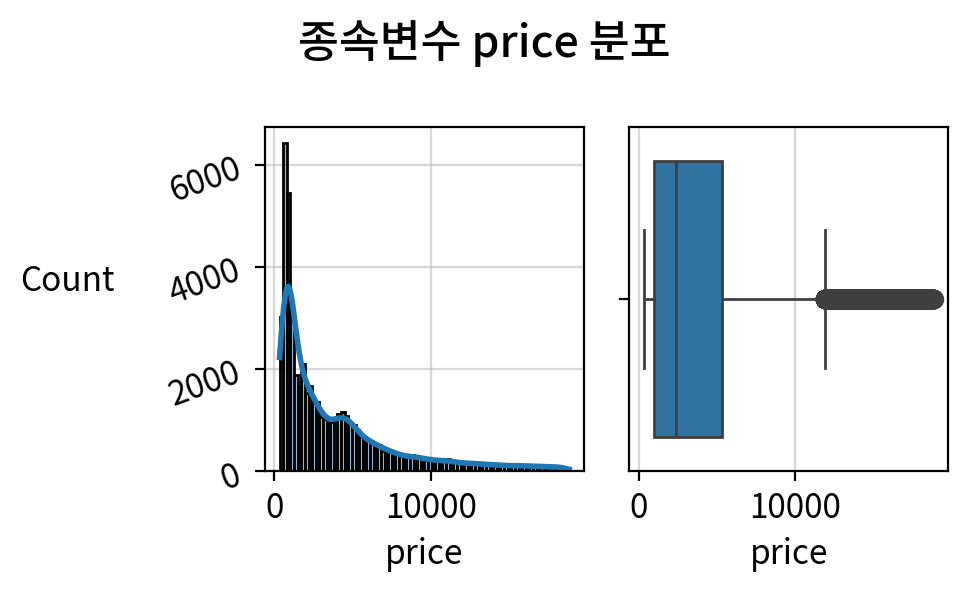

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
price,53794.000,3933.065,3988.114,326.000,951.000,2401.000,5326.750,18823.000,0.638,매우 큰 차이,4375.750,11890.375,-5612.625,3523,0.065,0,0.000,3523,0.065,1.618,오른쪽으로 긴 꼬리,2.178,약간 쏠려있음,log


[1순위] 위치 (Peak X): 862.0080 | 밀도값: 0.0003


,점검 항목,price 관찰 내용
0,분포 모양 (왜도),1.62 이므로 우편향 (오른쪽으로 치우침)
1,봉우리 수,1 개
2,이상치,6.55 %
3,가장 많이 분포,862.008 에 가장 많이 분포
4,로그 변환 진단결과,log
5,실제 진단결과,로그 변환 필요


In [15]:
# 종속변수 분포 확인

기술통계량_결과 , 종속변수_확인_결과 = my_EDA.종속변수_분포_확인(카테고리_변환 , 종속변수 , 가로 = 500 , 세로 = 300)

In [16]:
기술통계량_결과

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
price,53794.000,3933.065,3988.114,326.000,951.000,2401.000,5326.750,18823.000,0.638,매우 큰 차이,4375.750,11890.375,-5612.625,3523,0.065,0,0.000,3523,0.065,1.618,오른쪽으로 긴 꼬리,2.178,약간 쏠려있음,log


In [17]:
종속변수_확인_결과

,점검 항목,price 관찰 내용
0,분포 모양 (왜도),1.62 이므로 우편향 (오른쪽으로 치우침)
1,봉우리 수,1 개
2,이상치,6.55 %
3,가장 많이 분포,862.008 에 가장 많이 분포
4,로그 변환 진단결과,log
5,실제 진단결과,로그 변환 필요


y축 세우기 (다중 플롯)
그래프를 그렸습니다


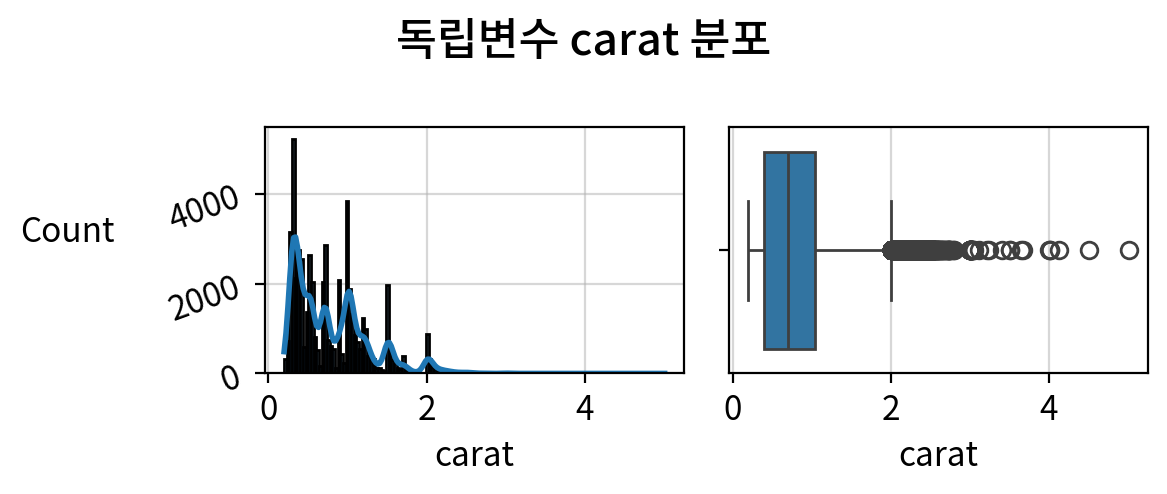

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
carat,53794.000,0.798,0.473,0.200,0.400,0.700,1.040,5.010,0.140,유의미한 차이,0.640,2.000,-0.560,1873,0.035,0,0.000,1873,0.035,1.114,오른쪽으로 긴 꼬리,1.247,약간 쏠려있음,log


[1순위] 위치 (Peak X): 0.3316 | 밀도값: 1.6885
[2순위] 위치 (Peak X): 1.0201 | 밀도값: 1.0072
[3순위] 위치 (Peak X): 0.5020 | 밀도값: 0.9570
[4순위] 위치 (Peak X): 0.7133 | 밀도값: 0.8150
[5순위] 위치 (Peak X): 1.5177 | 밀도값: 0.3832


관찰 내용
독립변수명 점검 항목                                
carat 분포 모양 (왜도)   1.11 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             5 개
      이상치                            3.48 %
      가장 많이 분포             0.332 에 가장 많이 분포
      2 번째로 많이 분포        1.02 에 2 번째로 많이 분포
      3 번째로 많이 분포       0.502 에 3 번째로 많이 분포
      4 번째로 많이 분포       0.713 에 4 번째로 많이 분포
      5 번째로 많이 분포       1.518 에 5 번째로 많이 분포
      로그 변환 진단결과                        log
      실제 진단결과                      로그 변환 필요

y축 세우기 (다중 플롯)
그래프를 그렸습니다


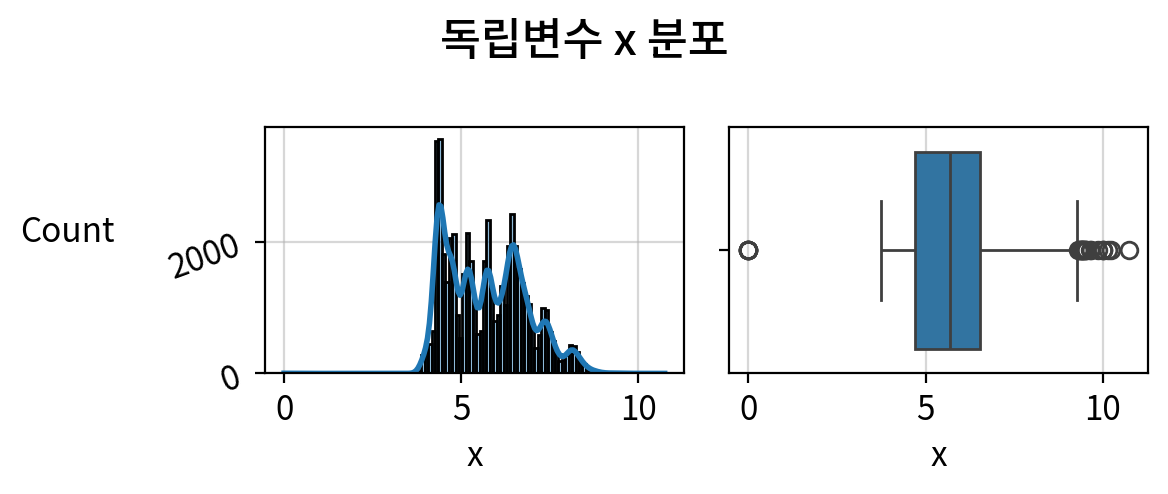

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
x,53794.000,5.731,1.121,0.000,4.710,5.700,6.540,10.740,0.005,거의 비슷함,1.830,9.285,1.965,24,0.000,7,0.000,31,0.001,0.380,좌우 대칭,-0.629,약간 평평함,none


[1순위] 위치 (Peak X): 4.3944 | 밀도값: 0.4953
[2순위] 위치 (Peak X): 6.4604 | 밀도값: 0.3763
[3순위] 위치 (Peak X): 5.1978 | 밀도값: 0.3048
[4순위] 위치 (Peak X): 5.7462 | 밀도값: 0.3035
[5순위] 위치 (Peak X): 7.3658 | 밀도값: 0.1530


관찰 내용
독립변수명 점검 항목                                
x     분포 모양 (왜도)   0.38 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             5 개
      이상치                            0.06 %
      가장 많이 분포             4.394 에 가장 많이 분포
      2 번째로 많이 분포        6.46 에 2 번째로 많이 분포
      3 번째로 많이 분포       5.198 에 3 번째로 많이 분포
      4 번째로 많이 분포       5.746 에 4 번째로 많이 분포
      5 번째로 많이 분포       7.366 에 5 번째로 많이 분포
      로그 변환 진단결과                       none
      실제 진단결과                  이상치만 점검 후 진행

y축 세우기 (다중 플롯)
그래프를 그렸습니다


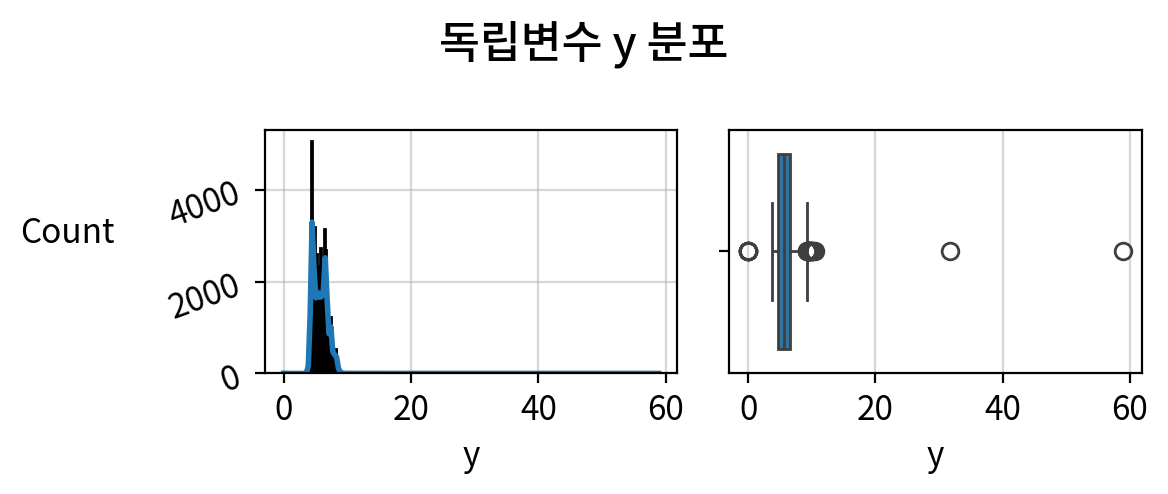

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
y,53794.000,5.735,1.141,0.000,4.720,5.710,6.540,58.900,0.004,거의 비슷함,1.820,9.270,1.990,22,0.000,6,0.000,28,0.001,2.446,오른쪽으로 긴 꼬리,91.752,약간 쏠려있음,log1p


[1순위] 위치 (Peak X): 4.4255 | 밀도값: 0.4886
[2순위] 위치 (Peak X): 6.4372 | 밀도값: 0.3748
[3순위] 위치 (Peak X): 5.7667 | 밀도값: 0.3007
[4순위] 위치 (Peak X): 5.2180 | 밀도값: 0.2997
[5순위] 위치 (Peak X): 7.3517 | 밀도값: 0.1507


관찰 내용
독립변수명 점검 항목                                
y     분포 모양 (왜도)   2.45 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             5 개
      이상치                            0.05 %
      가장 많이 분포             4.426 에 가장 많이 분포
      2 번째로 많이 분포       6.437 에 2 번째로 많이 분포
      3 번째로 많이 분포       5.767 에 3 번째로 많이 분포
      4 번째로 많이 분포       5.218 에 4 번째로 많이 분포
      5 번째로 많이 분포       7.352 에 5 번째로 많이 분포
      로그 변환 진단결과                      log1p
      실제 진단결과                 로그 더하기1 변환 필요

y축 세우기 (다중 플롯)
그래프를 그렸습니다


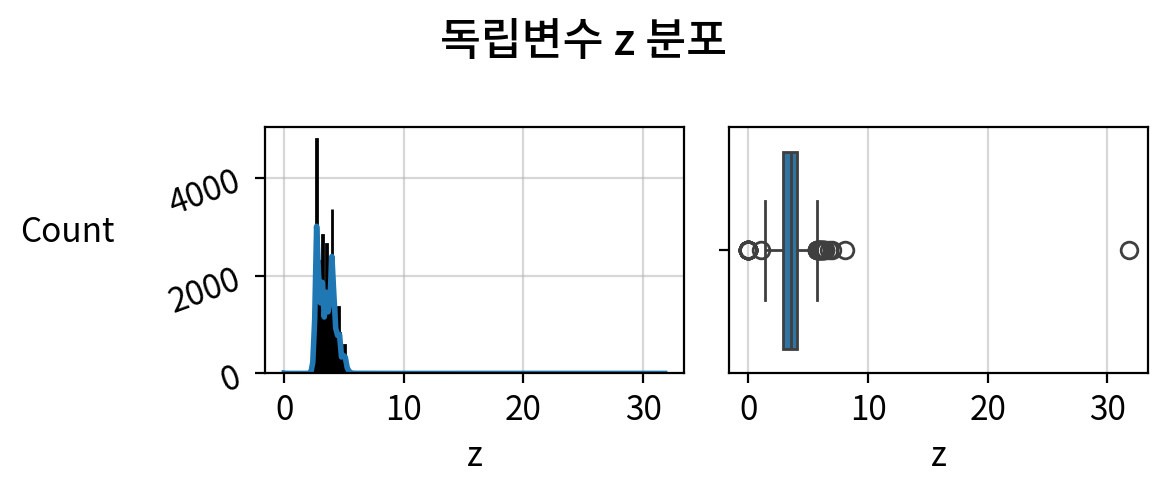

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
z,53794.000,3.539,0.705,0.000,2.910,3.530,4.030,31.800,0.002,거의 비슷함,1.120,5.710,1.230,28,0.001,20,0.000,48,0.001,1.529,오른쪽으로 긴 꼬리,47.384,약간 쏠려있음,log1p


[1순위] 위치 (Peak X): 2.7217 | 밀도값: 0.8176
[2순위] 위치 (Peak X): 4.0074 | 밀도값: 0.6503
[3순위] 위치 (Peak X): 3.1954 | 밀도값: 0.5061
[4순위] 위치 (Peak X): 3.5676 | 밀도값: 0.4767
[5순위] 위치 (Peak X): 4.5487 | 밀도값: 0.2509


관찰 내용
독립변수명 점검 항목                                
z     분포 모양 (왜도)   1.53 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             5 개
      이상치                            0.09 %
      가장 많이 분포             2.722 에 가장 많이 분포
      2 번째로 많이 분포       4.007 에 2 번째로 많이 분포
      3 번째로 많이 분포       3.195 에 3 번째로 많이 분포
      4 번째로 많이 분포       3.568 에 4 번째로 많이 분포
      5 번째로 많이 분포       4.549 에 5 번째로 많이 분포
      로그 변환 진단결과                      log1p
      실제 진단결과                 로그 더하기1 변환 필요

y축 세우기 (다중 플롯)
그래프를 그렸습니다


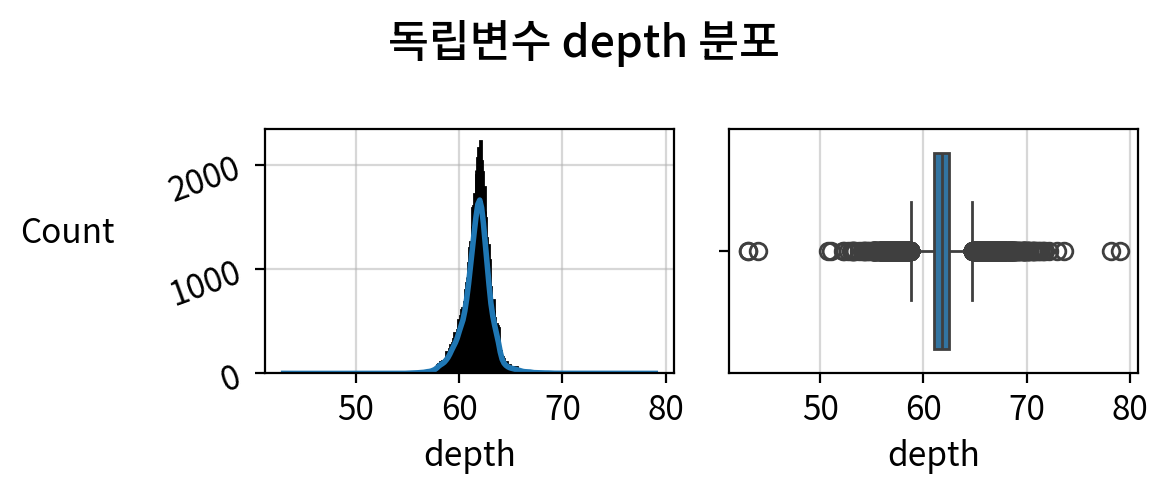

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
depth,53794.000,61.748,1.430,43.000,61.000,61.800,62.500,79.000,0.001,거의 비슷함,1.500,64.750,58.750,1027,0.019,1498,0.028,2525,0.047,-0.114,좌우 대칭,5.413,약간 쏠려있음,none


[1순위] 위치 (Peak X): 61.9700 | 밀도값: 0.3894


관찰 내용
독립변수명 점검 항목                               
depth 분포 모양 (왜도)  -0.11 이므로 좌편향 (왼쪽으로 치우침)
      봉우리 수                            1 개
      이상치                           4.69 %
      가장 많이 분포            61.97 에 가장 많이 분포
      로그 변환 진단결과                      none
      실제 진단결과                 이상치만 점검 후 진행

y축 세우기 (다중 플롯)
그래프를 그렸습니다


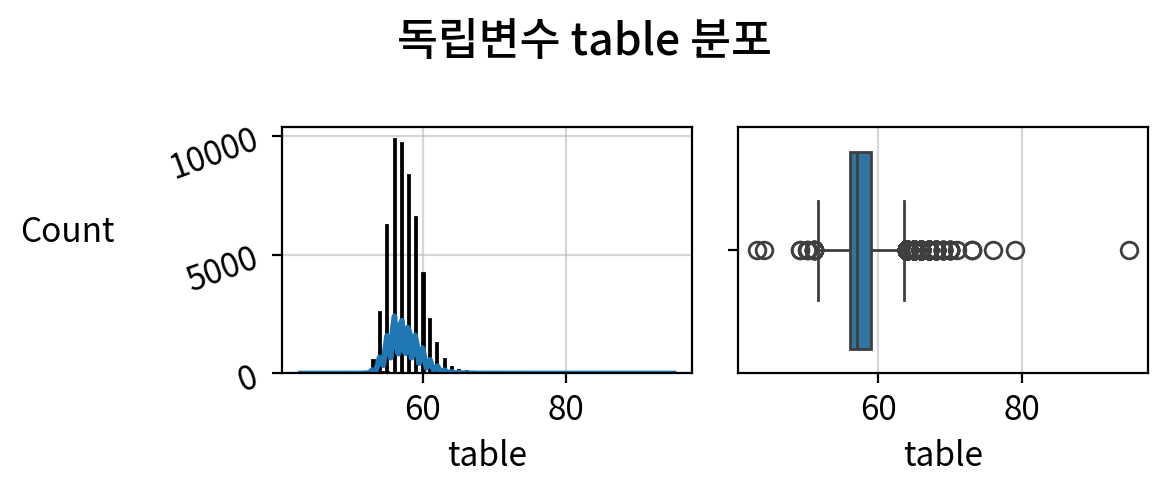

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
table,53794.000,57.458,2.234,43.000,56.000,57.000,59.000,95.000,0.008,거의 비슷함,3.000,63.500,51.500,588,0.011,16,0.000,604,0.011,0.792,오른쪽으로 긴 꼬리,2.775,약간 쏠려있음,log


[1순위] 위치 (Peak X): 56.0000 | 밀도값: 0.2918
[2순위] 위치 (Peak X): 56.9730 | 밀도값: 0.2845
[3순위] 위치 (Peak X): 58.0000 | 밀도값: 0.2463
[4순위] 위치 (Peak X): 58.9730 | 밀도값: 0.1923
[5순위] 위치 (Peak X): 55.0270 | 밀도값: 0.1854


관찰 내용
독립변수명 점검 항목                                
table 분포 모양 (왜도)   0.79 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             9 개
      이상치                            1.12 %
      가장 많이 분포              56.0 에 가장 많이 분포
      2 번째로 많이 분포      56.973 에 2 번째로 많이 분포
      3 번째로 많이 분포        58.0 에 3 번째로 많이 분포
      4 번째로 많이 분포      58.973 에 4 번째로 많이 분포
      5 번째로 많이 분포      55.027 에 5 번째로 많이 분포
      로그 변환 진단결과                        log
      실제 진단결과                      로그 변환 필요

관찰 내용
독립변수명 점검 항목                                
carat 분포 모양 (왜도)   1.11 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             5 개
      이상치                            3.48 %
      가장 많이 분포             0.332 에 가장 많이 분포
      2 번째로 많이 분포        1.02 에 2 번째로 많이 분포
      3 번째로 많이 분포       0.502 에 3 번째로 많이 분포
      4 번째로 많이 분포       0.713 에 4 번째로 많이 분포
      5 번째로 많이 분포       1.518 에 5 번째로 많이 분포
      로그 변환 진단결과                        log
      실제 진단결과                      로그 변환 필요
x     분포 모양 (왜도)   0.38 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             5 개
      이상치                            0.06 %
      가장 많이 분포             4.394 에 가장 많이 분포
      2 번째로 많이 분포        6.46 에 2 번째로 많이 분포
      3 번째로 많이 분포       5.198 에 3 번째로 많이 분포
      4 번째로 많이 분포       5.746 에 4 번째로 많이 분포
      5 번째로 많이 분포       7.366 에 5 번째로 많이 분포
      로그 변환 진단결과                       none
      실제 진단결과                  이상치만 점검 후 진행
y     분포 모양 (왜도)   2.45 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             5 개
      이상치                            0.05 %
      가장 많이 분포             4.426 에 가장 많이 분포
      2 번째로 많이 분포       6.437 에 2 번째로 많이 분포
      3 번째로 많이 분포       5.767 에 3 번째로 많이 분포
      4 번째로 많이 분포       5.218 에 4 번째로 많이 분포
      5 번째로 많이 분포       7.352 에 5 번째로 많이 분포
      로그 변환 진단결과                      log1p
      실제 진단결과                 로그 더하기1 변환 필요
z     분포 모양 (왜도)   1.53 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             5 개
      이상치                            0.09 %
      가장 많이 분포             2.722 에 가장 많이 분포
      2 번째로 많이 분포       4.007 에 2 번째로 많이 분포
      3 번째로 많이 분포       3.195 에 3 번째로 많이 분포
      4 번째로 많이 분포       3.568 에 4 번째로 많이 분포
      5 번째로 많이 분포       4.549 에 5 번째로 많이 분포
      로그 변환 진단결과                      log1p
      실제 진단결과                 로그 더하기1 변환 필요
depth 분포 모양 (왜도)   -0.11 이므로 좌편향 (왼쪽으로 치우침)
      봉우리 수                             1 개
      이상치                            4.69 %
      가장 많이 분포             61.97 에 가장 많이 분포
      로그 변환 진단결과                       none
      실제 진단결과                  이상치만 점검 후 진행
table 분포 모양 (왜도)   0.79 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             9 개
      이상치                            1.12 %
      가장 많이 분포              56.0 에 가장 많이 분포
      2 번째로 많이 분포      56.973 에 2 번째로 많이 분포
      3 번째로 많이 분포        58.0 에 3 번째로 많이 분포
      4 번째로 많이 분포      58.973 에 4 번째로 많이 분포
      5 번째로 많이 분포      55.027 에 5 번째로 많이 분포
      로그 변환 진단결과                        log
      실제 진단결과                      로그 변환 필요

In [18]:
# 독립변수 연속형 단변량 분석

연속형_단변량_분석_결과 = my_EDA.독립변수_연속형_단변량_분석(카테고리_변환 , 연속형_변수 , 가로 = 600 , 세로 = 250)

y축 세우기 (단일 플롯)
그래프를 그렸습니다


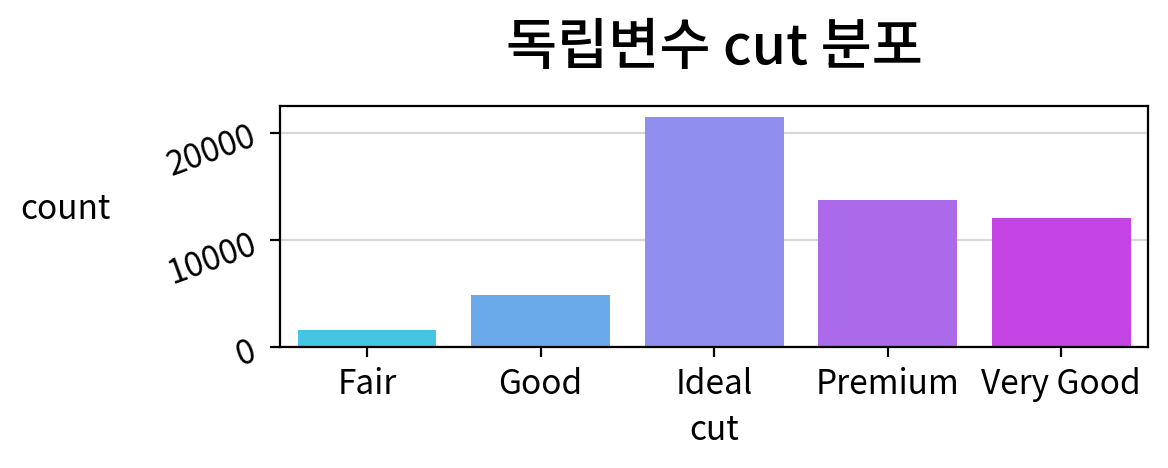

,count,unique,top,freq
cut,53794,5,Ideal,21488


,빈도,비율
cut,,
Ideal,21488,0.399
Premium,13748,0.256
Very Good,12069,0.224
Good,4891,0.091
Fair,1598,0.030


[경고] 독립변수 'cut'는 불균형 분포로 판단됩니다!
 - 최소 클래스 비율: 0.03 (기준: 10.0% 미만)
 - 최대/최소 비율 격차: 13.45배 (기준: 1.5배 이상)

y축 세우기 (단일 플롯)
그래프를 그렸습니다


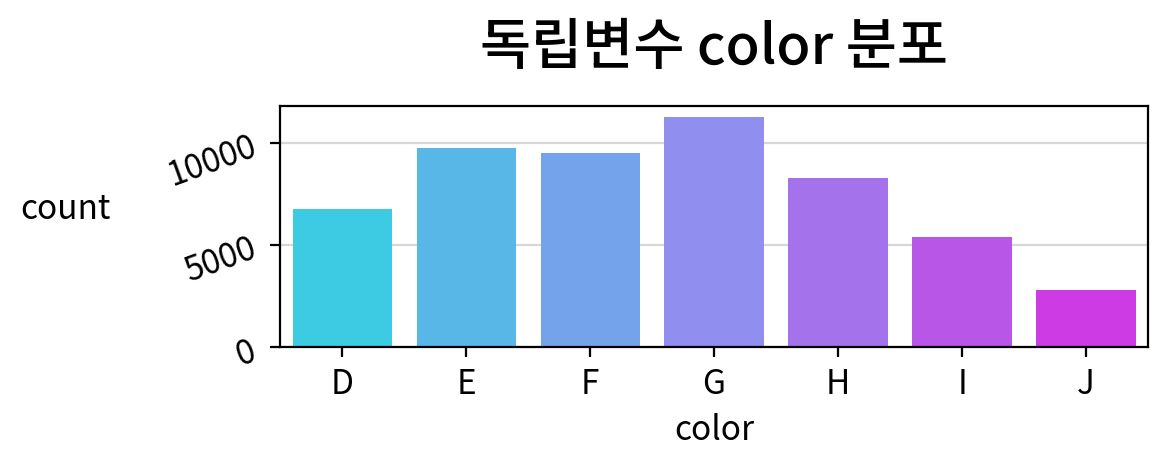

,count,unique,top,freq
color,53794,7,G,11262


,빈도,비율
color,,
G,11262,0.209
E,9776,0.182
F,9520,0.177
H,8272,0.154
D,6755,0.126
I,5407,0.101
J,2802,0.052


[경고] 독립변수 'color'는 불균형 분포로 판단됩니다!
 - 최소 클래스 비율: 0.05 (기준: 7.1% 미만)
 - 최대/최소 비율 격차: 4.02배 (기준: 1.5배 이상)

y축 세우기 (단일 플롯)
그래프를 그렸습니다


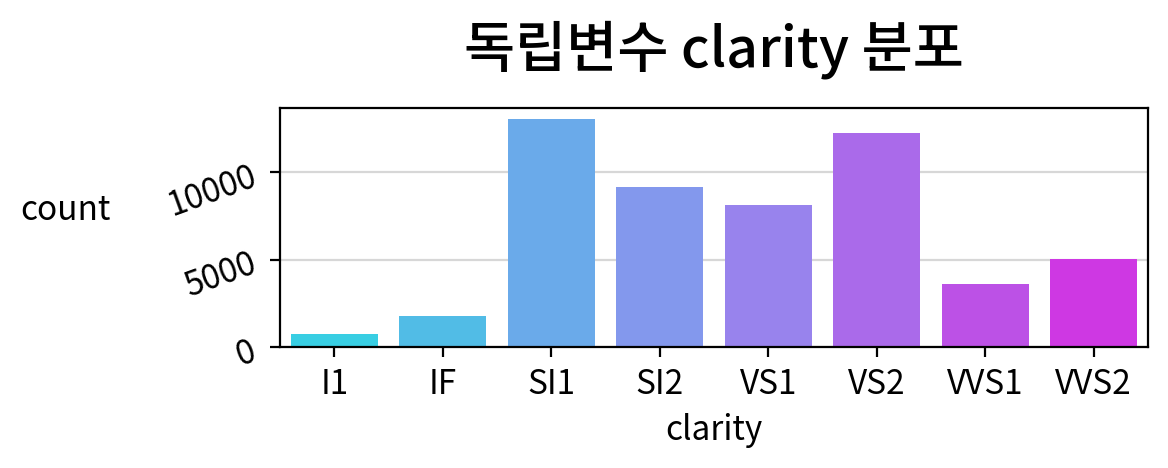

,count,unique,top,freq
clarity,53794,8,SI1,13032


,빈도,비율
clarity,,
SI1,13032,0.242
VS2,12229,0.227
SI2,9150,0.170
VS1,8156,0.152
VVS2,5056,0.094
VVS1,3647,0.068
IF,1784,0.033
I1,740,0.014


[경고] 독립변수 'clarity'는 불균형 분포로 판단됩니다!
 - 최소 클래스 비율: 0.01 (기준: 6.2% 미만)
 - 최대/최소 비율 격차: 17.61배 (기준: 1.5배 이상)



,독립변수명,최소비율,불균형 여부
0,cut,0.030,True
0,color,0.052,True
0,clarity,0.014,True


,독립변수명,도메인,빈도,비율
0,cut,Ideal,21488,0.399
1,cut,Premium,13748,0.256
2,cut,Very Good,12069,0.224
3,cut,Good,4891,0.091
4,cut,Fair,1598,0.030
0,color,G,11262,0.209
1,color,E,9776,0.182
2,color,F,9520,0.177
3,color,H,8272,0.154
4,color,D,6755,0.126


In [19]:
# 독립변수 명목형 단변량 분석

명목형_단변량_분석_결과 , 명목형_빈도수 = my_EDA.독립변수_명목형_단변량_분석(카테고리_변환 , 명목형_변수 , 가로 = 600 , 세로 = 250)

In [20]:
명목형_단변량_분석_결과

,독립변수명,최소비율,불균형 여부
0,cut,0.030,True
0,color,0.052,True
0,clarity,0.014,True


In [21]:
명목형_빈도수

,독립변수명,도메인,빈도,비율
0,cut,Ideal,21488,0.399
1,cut,Premium,13748,0.256
2,cut,Very Good,12069,0.224
3,cut,Good,4891,0.091
4,cut,Fair,1598,0.030
0,color,G,11262,0.209
1,color,E,9776,0.182
2,color,F,9520,0.177
3,color,H,8272,0.154
4,color,D,6755,0.126


#### carat -> price

y축 세우기 (단일 플롯)
그래프를 그렸습니다


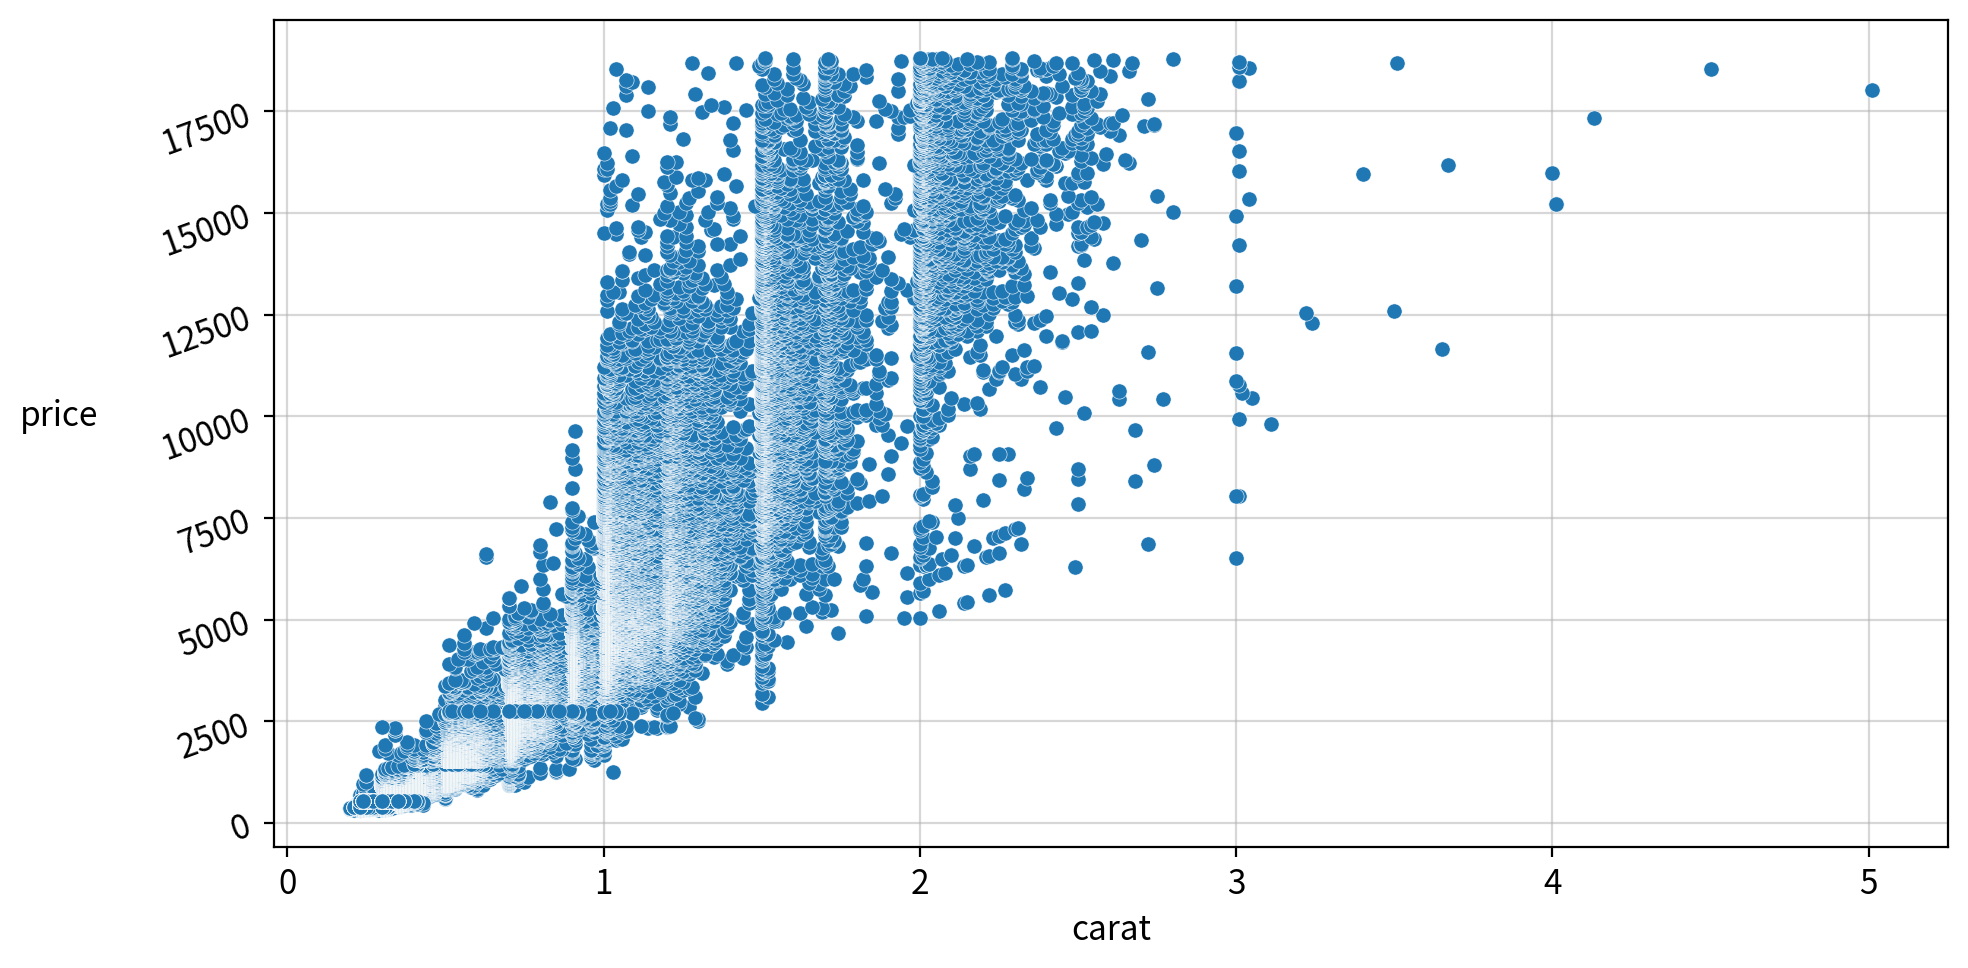

,,검정방법,상관계수,p값,강도결과,유의미한 차이 여부,X 정규성,Y 정규성,선형 여부,이상치 여부,왜도 여부
x,y,,,,,,,,,,
carat,price,스피어만 (Spearman),0.963,0.000,많이 강함,True,False,False,False,False,True


1순위 밀도 위치: X = 0.3293, Y = 789.7990 (밀도: 0.0014)
2순위 밀도 위치: X = 0.7057, Y = 2463.0754 (밀도: 0.0005)


관찰 내용
독립변수명 확인 항목                                                    
carat 선형 / 비선형                         선형 여부는 비선형  /  관계는 양의 관계
      단조성                    단조성은 대체로 증가 (carat 증가 -> price 증가)
      1순위 밀도 위치         carat = 0.329 , price = 789.799 에 많이 분포
      2순위 밀도 위치        carat = 0.706 , price = 2463.075 에 많이 분포
      이상치           왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부      채택!! 유의미한 양의 상관으로 강도는 많이 강함  /  상관 계수 및 p 값 참고

#### x -> price

y축 세우기 (단일 플롯)
그래프를 그렸습니다


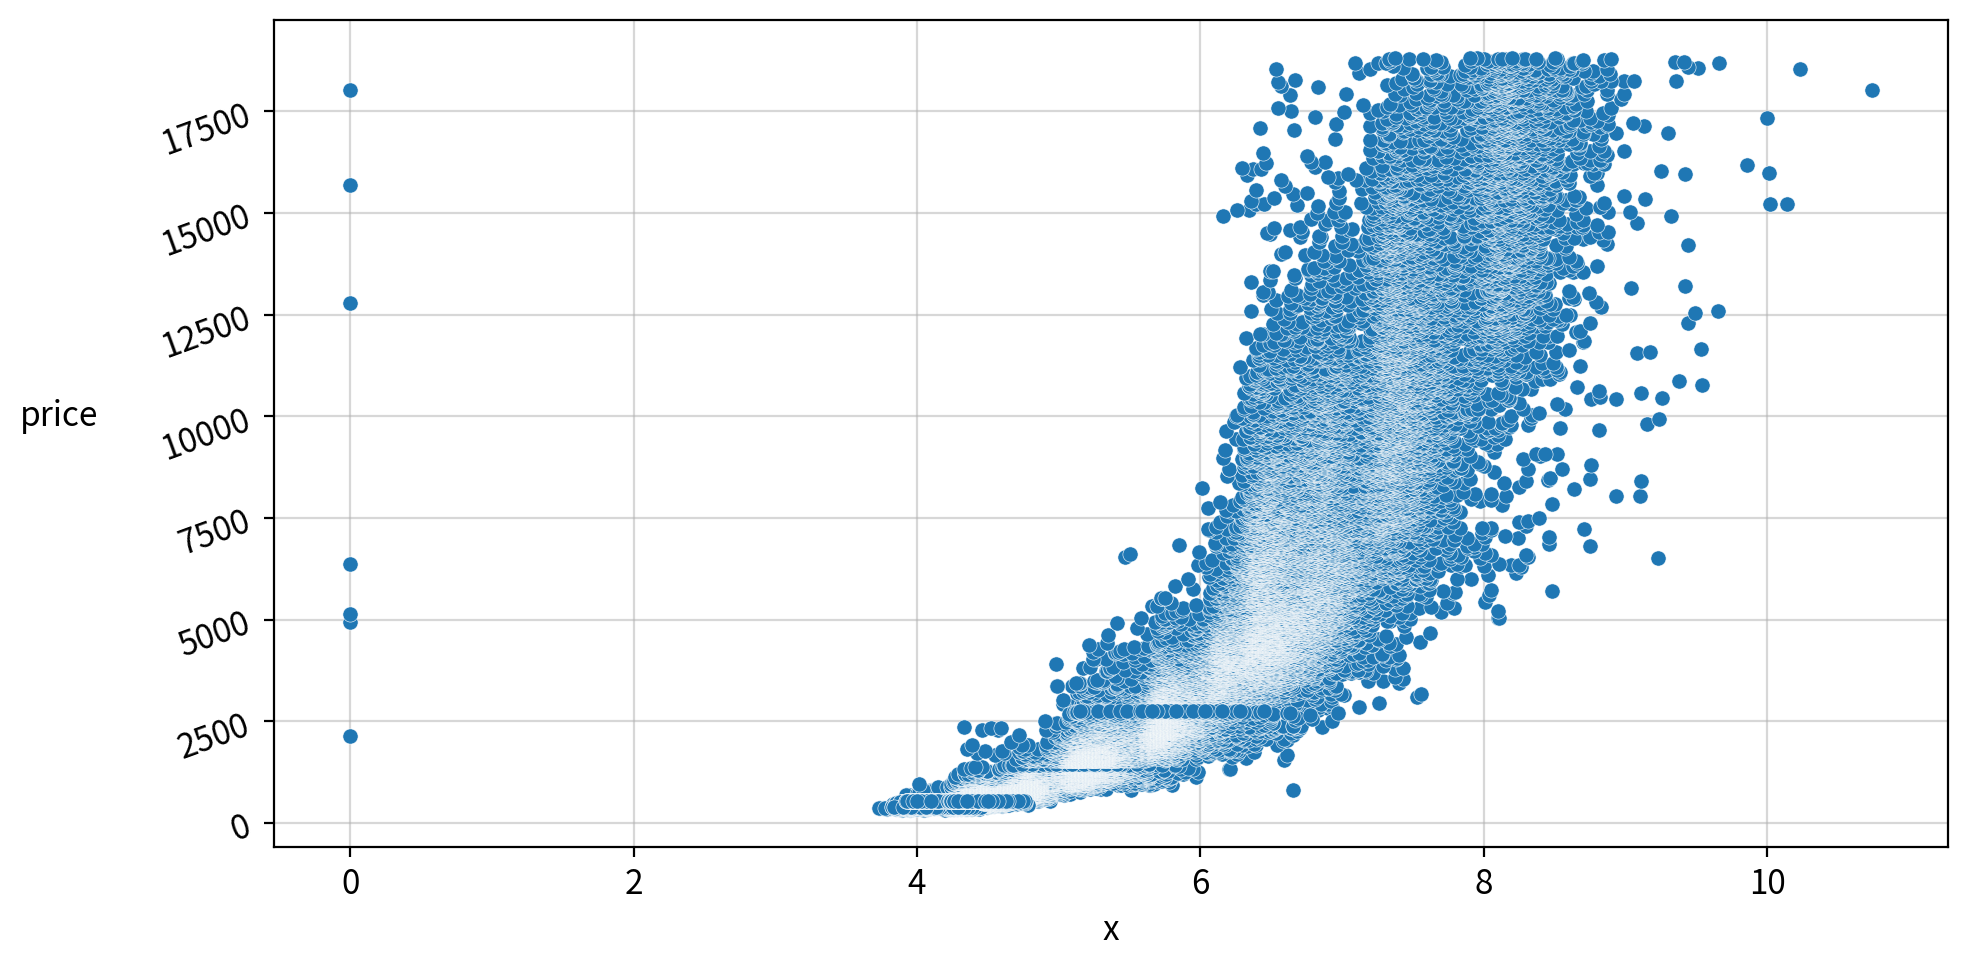

,,검정방법,상관계수,p값,강도결과,유의미한 차이 여부,X 정규성,Y 정규성,선형 여부,이상치 여부,왜도 여부
x,y,,,,,,,,,,
x,price,스피어만 (Spearman),0.963,0.000,많이 강함,True,False,False,False,False,True


1순위 밀도 위치: X = 4.3777, Y = 696.8392 (밀도: 0.0004)
2순위 밀도 위치: X = 5.7221, Y = 2556.0352 (밀도: 0.0002)


관찰 내용
독립변수명 확인 항목                                                    
x     선형 / 비선형                         선형 여부는 비선형  /  관계는 양의 관계
      단조성                        단조성은 대체로 증가 (x 증가 -> price 증가)
      1순위 밀도 위치             x = 4.378 , price = 696.839 에 많이 분포
      2순위 밀도 위치            x = 5.722 , price = 2556.035 에 많이 분포
      이상치           왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부      채택!! 유의미한 양의 상관으로 강도는 많이 강함  /  상관 계수 및 p 값 참고

#### y -> price

y축 세우기 (단일 플롯)
그래프를 그렸습니다


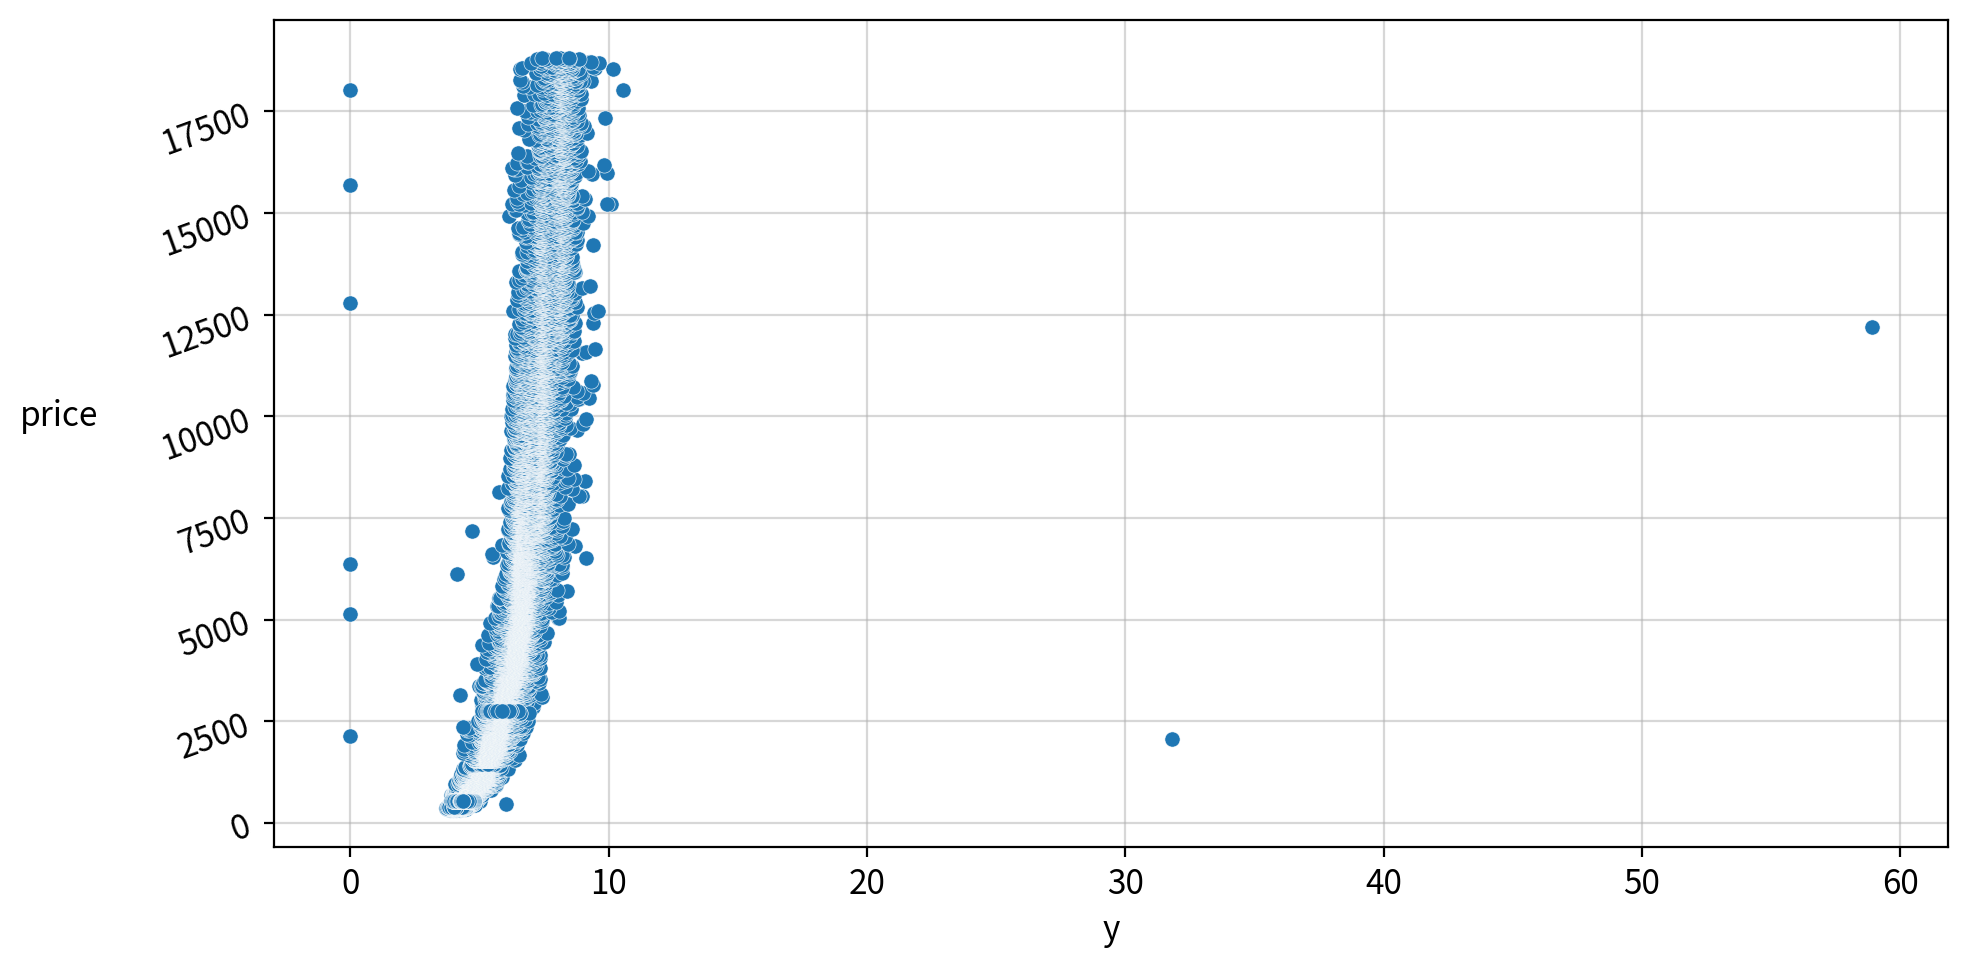

,,검정방법,상관계수,p값,강도결과,유의미한 차이 여부,X 정규성,Y 정규성,선형 여부,이상치 여부,왜도 여부
x,y,,,,,,,,,,
y,price,스피어만 (Spearman),0.963,0.000,많이 강함,True,False,False,False,False,True


1순위 밀도 위치: X = 4.5085, Y = 975.7186 (밀도: 0.0003)
2순위 밀도 위치: X = 5.7327, Y = 2834.9146 (밀도: 0.0001)


관찰 내용
독립변수명 확인 항목                                                    
y     선형 / 비선형                         선형 여부는 비선형  /  관계는 양의 관계
      단조성                        단조성은 대체로 증가 (y 증가 -> price 증가)
      1순위 밀도 위치             y = 4.509 , price = 975.719 에 많이 분포
      2순위 밀도 위치            y = 5.733 , price = 2834.915 에 많이 분포
      이상치           왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부      채택!! 유의미한 양의 상관으로 강도는 많이 강함  /  상관 계수 및 p 값 참고

#### z -> price

y축 세우기 (단일 플롯)
그래프를 그렸습니다


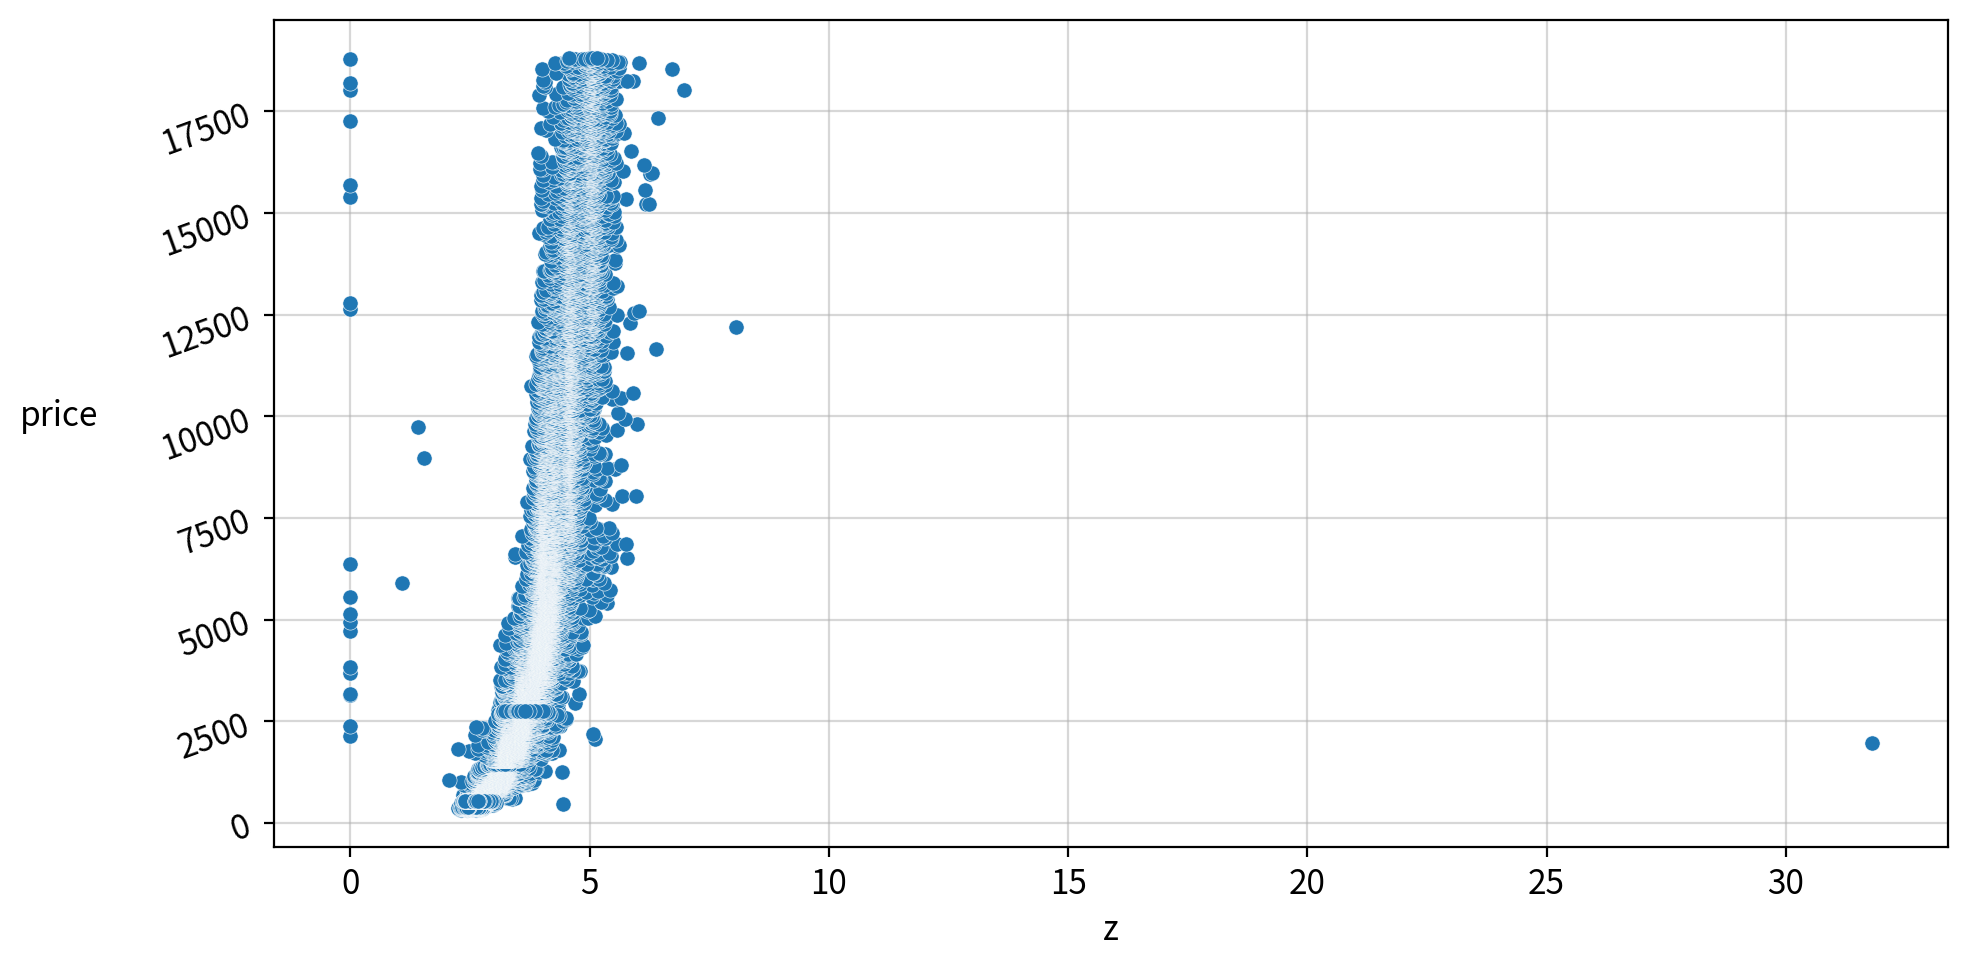

,,검정방법,상관계수,p값,강도결과,유의미한 차이 여부,X 정규성,Y 정규성,선형 여부,이상치 여부,왜도 여부
x,y,,,,,,,,,,
z,price,스피어만 (Spearman),0.957,0.000,많이 강함,True,False,False,False,False,True


1순위 밀도 위치: X = 2.7367, Y = 789.7990 (밀도: 0.0006)
2순위 밀도 위치: X = 3.5859, Y = 2741.9548 (밀도: 0.0002)


관찰 내용
독립변수명 확인 항목                                                    
z     선형 / 비선형                         선형 여부는 비선형  /  관계는 양의 관계
      단조성                        단조성은 대체로 증가 (z 증가 -> price 증가)
      1순위 밀도 위치             z = 2.737 , price = 789.799 에 많이 분포
      2순위 밀도 위치            z = 3.586 , price = 2741.955 에 많이 분포
      이상치           왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부      채택!! 유의미한 양의 상관으로 강도는 많이 강함  /  상관 계수 및 p 값 참고

#### depth -> price

y축 세우기 (단일 플롯)
그래프를 그렸습니다


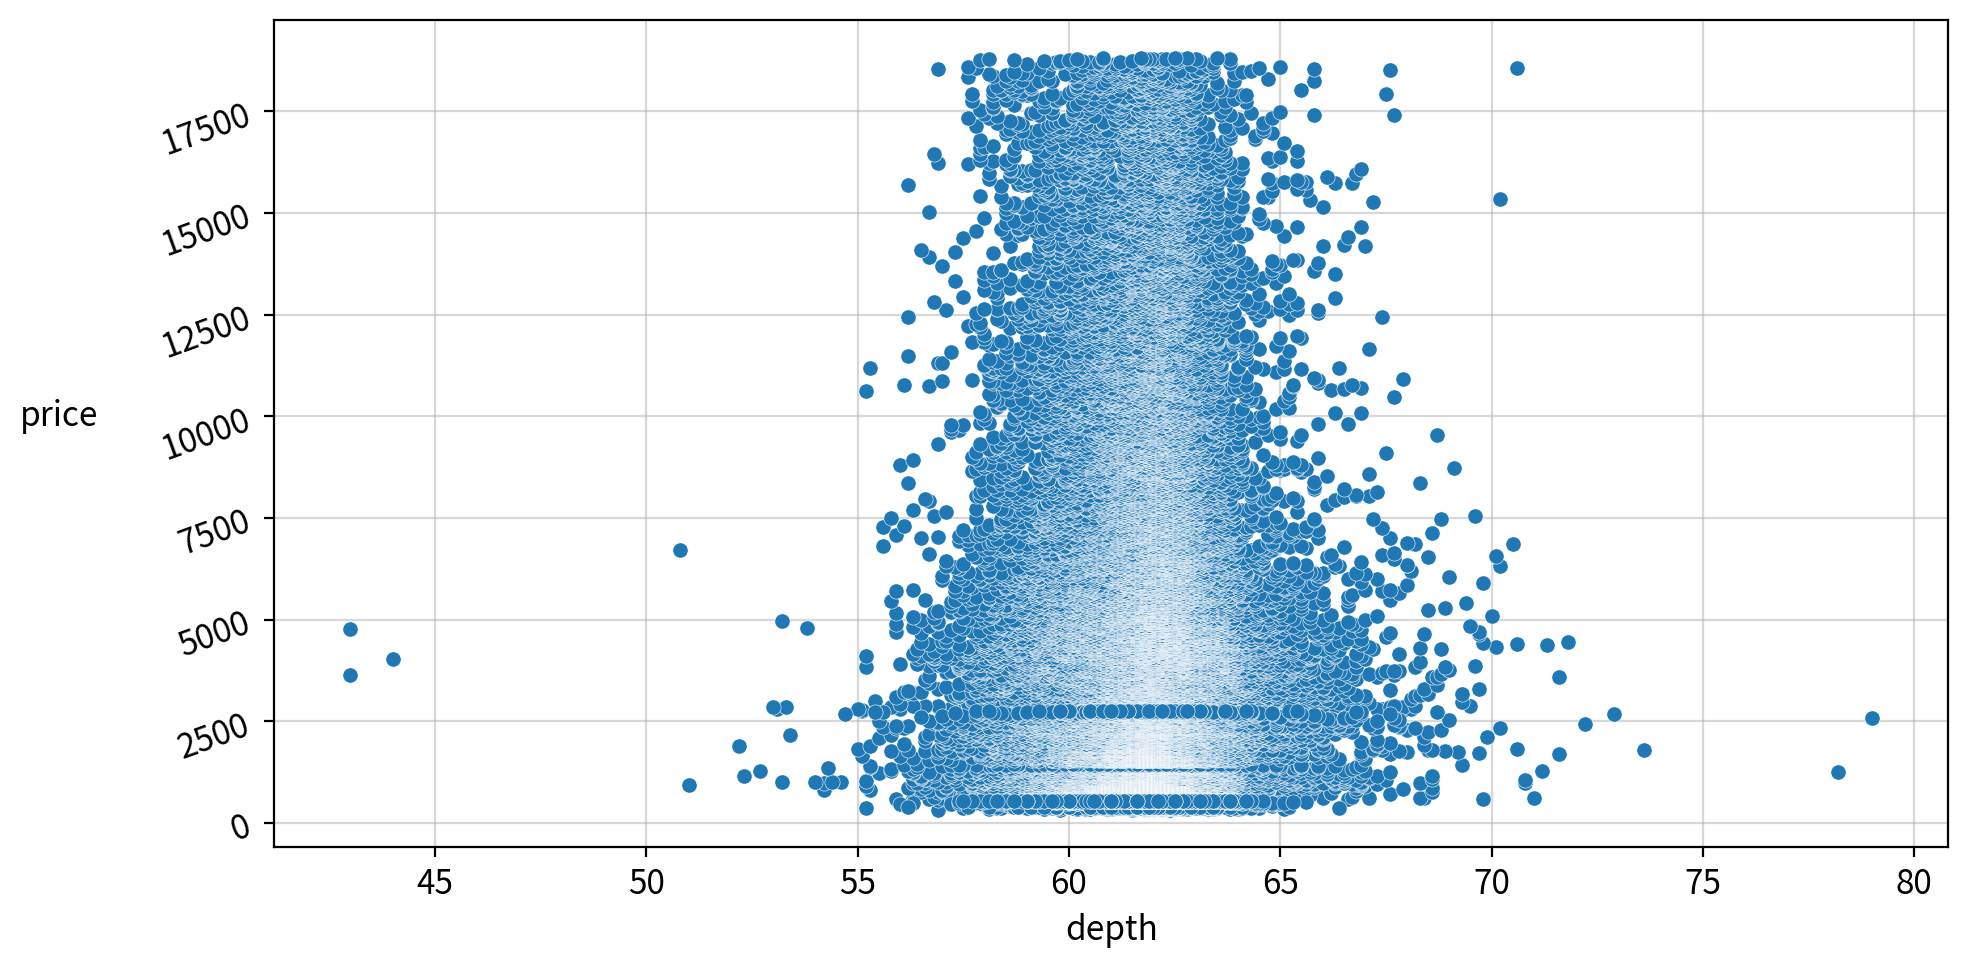

,,검정방법,상관계수,p값,강도결과,유의미한 차이 여부,X 정규성,Y 정규성,선형 여부,이상치 여부,왜도 여부
x,y,,,,,,,,,,
depth,price,스피어만 (Spearman),0.010,0.018,약함,True,False,False,False,False,True


1순위 밀도 위치: X = 61.8593, Y = 975.7186 (밀도: 0.0001)
2순위 밀도 위치: X = 62.0503, Y = 2834.9146 (밀도: 0.0000)


관찰 내용
독립변수명 확인 항목                                                 
depth 선형 / 비선형                      선형 여부는 비선형  /  관계는 양의 관계
      단조성                                         단조성은 거의 약함
      1순위 밀도 위치     depth = 61.859 , price = 975.719 에 많이 분포
      2순위 밀도 위치    depth = 62.050 , price = 2834.915 에 많이 분포
      이상치        왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부            상관 강도가 약하여 우선 제외!!  /  상관 계수 및 p 값 참고

#### table -> price

y축 세우기 (단일 플롯)
그래프를 그렸습니다


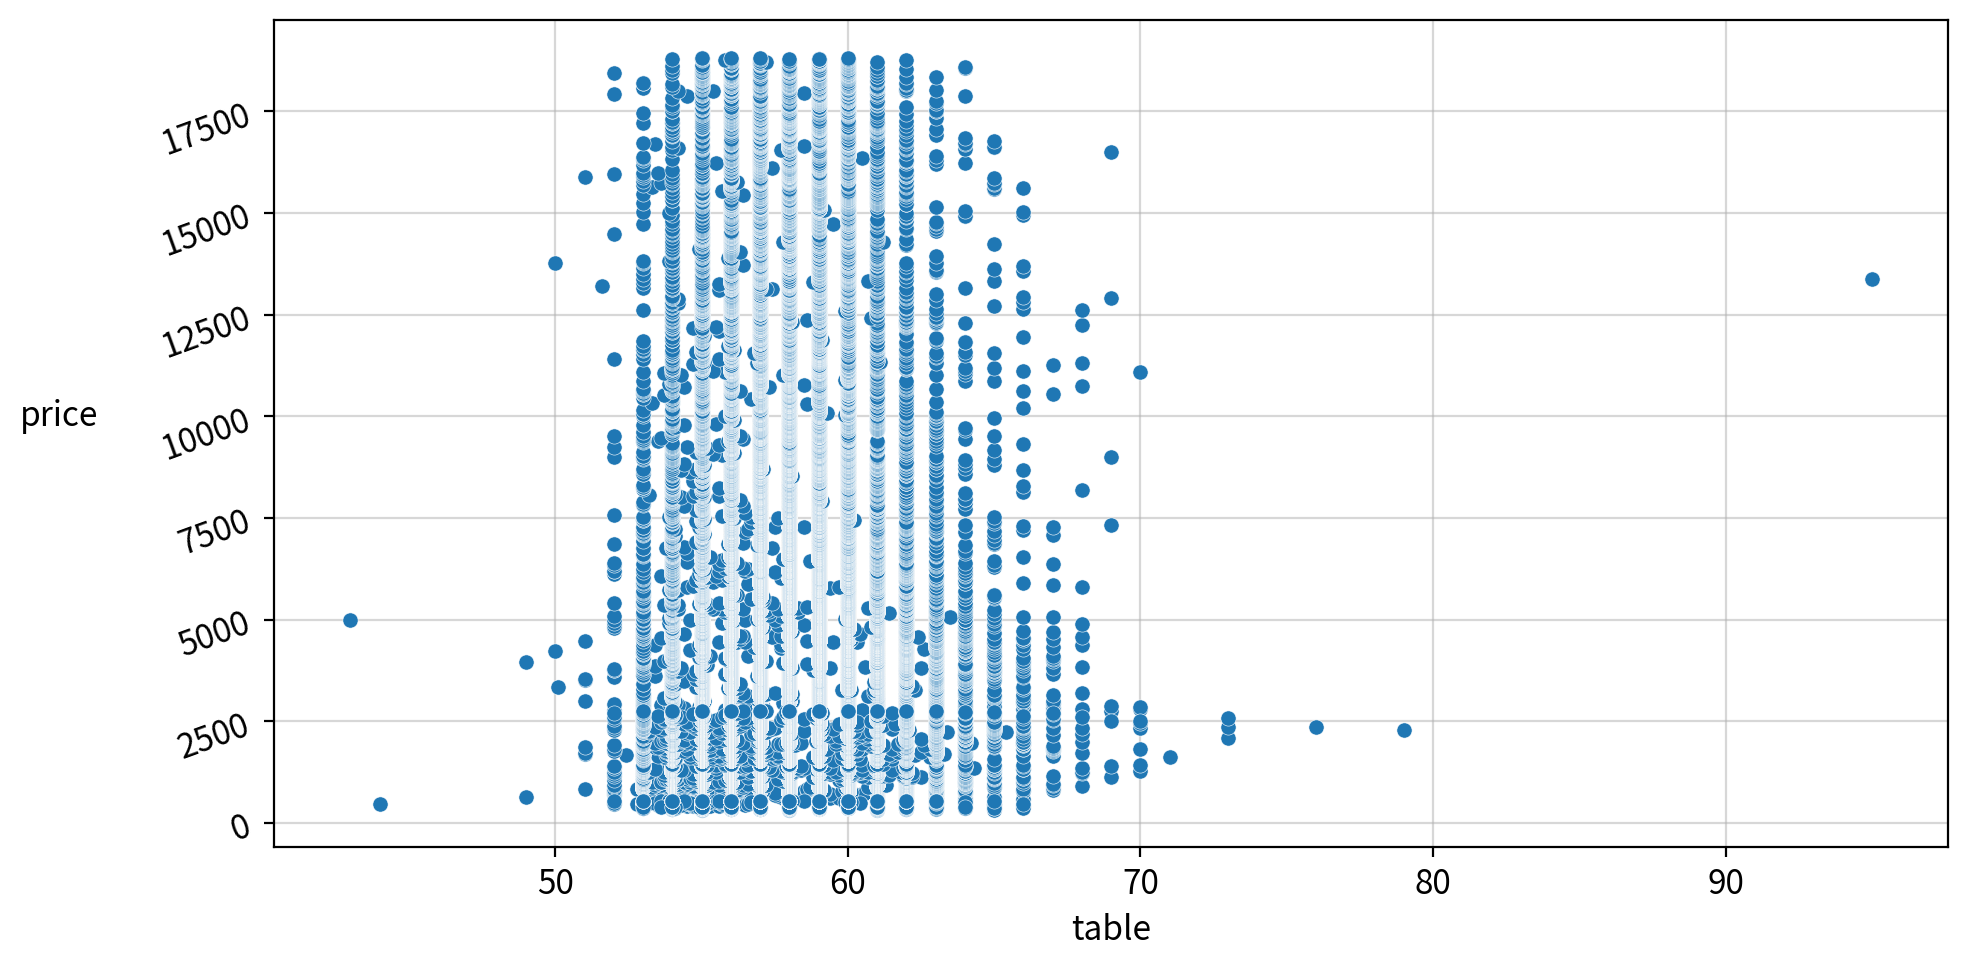

,,검정방법,상관계수,p값,강도결과,유의미한 차이 여부,X 정규성,Y 정규성,선형 여부,이상치 여부,왜도 여부
x,y,,,,,,,,,,
table,price,스피어만 (Spearman),0.171,0.000,약함,True,False,False,False,False,True


1순위 밀도 위치: X = 56.1106, Y = 1068.6784 (밀도: 0.0001)
2순위 밀도 위치: X = 56.9246, Y = 2927.8744 (밀도: 0.0000)


관찰 내용
독립변수명 확인 항목                                                 
table 선형 / 비선형                      선형 여부는 비선형  /  관계는 양의 관계
      단조성                                         단조성은 거의 약함
      1순위 밀도 위치    table = 56.111 , price = 1068.678 에 많이 분포
      2순위 밀도 위치    table = 56.925 , price = 2927.874 에 많이 분포
      이상치        왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부            상관 강도가 약하여 우선 제외!!  /  상관 계수 및 p 값 참고

관찰 내용
독립변수명 확인 항목                                                    
carat 선형 / 비선형                         선형 여부는 비선형  /  관계는 양의 관계
      단조성                    단조성은 대체로 증가 (carat 증가 -> price 증가)
      1순위 밀도 위치         carat = 0.329 , price = 789.799 에 많이 분포
      2순위 밀도 위치        carat = 0.706 , price = 2463.075 에 많이 분포
      이상치           왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부      채택!! 유의미한 양의 상관으로 강도는 많이 강함  /  상관 계수 및 p 값 참고
x     선형 / 비선형                         선형 여부는 비선형  /  관계는 양의 관계
      단조성                        단조성은 대체로 증가 (x 증가 -> price 증가)
      1순위 밀도 위치             x = 4.378 , price = 696.839 에 많이 분포
      2순위 밀도 위치            x = 5.722 , price = 2556.035 에 많이 분포
      이상치           왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부      채택!! 유의미한 양의 상관으로 강도는 많이 강함  /  상관 계수 및 p 값 참고
y     선형 / 비선형                         선형 여부는 비선형  /  관계는 양의 관계
      단조성                        단조성은 대체로 증가 (y 증가 -> price 증가)
      1순위 밀도 위치             y = 4.509 , price = 975.719 에 많이 분포
      2순위 밀도 위치            y = 5.733 , price = 2834.915 에 많이 분포
      이상치           왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부      채택!! 유의미한 양의 상관으로 강도는 많이 강함  /  상관 계수 및 p 값 참고
z     선형 / 비선형                         선형 여부는 비선형  /  관계는 양의 관계
      단조성                        단조성은 대체로 증가 (z 증가 -> price 증가)
      1순위 밀도 위치             z = 2.737 , price = 789.799 에 많이 분포
      2순위 밀도 위치            z = 3.586 , price = 2741.955 에 많이 분포
      이상치           왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부      채택!! 유의미한 양의 상관으로 강도는 많이 강함  /  상관 계수 및 p 값 참고
depth 선형 / 비선형                         선형 여부는 비선형  /  관계는 양의 관계
      단조성                                            단조성은 거의 약함
      1순위 밀도 위치        depth = 61.859 , price = 975.719 에 많이 분포
      2순위 밀도 위치       depth = 62.050 , price = 2834.915 에 많이 분포
      이상치           왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부               상관 강도가 약하여 우선 제외!!  /  상관 계수 및 p 값 참고
table 선형 / 비선형                         선형 여부는 비선형  /  관계는 양의 관계
      단조성                                            단조성은 거의 약함
      1순위 밀도 위치       table = 56.111 , price = 1068.678 에 많이 분포
      2순위 밀도 위치       table = 56.925 , price = 2927.874 에 많이 분포
      이상치           왜곡은 있으나 약간의 극단치만 보일 가능성이 높음  /  다만 별도 확인 필요
      채택 여부               상관 강도가 약하여 우선 제외!!  /  상관 계수 및 p 값 참고

In [22]:
# 상관 분석

결과확인 = my_EDA.독립변수_연속형_상관분석(카테고리_변환 , 연속형_변수 , 종속변수)

In [23]:
# 두 개 고유 값 분석

# t검정_결과확인 , t검정_결과_간단확인 = my_EDA.두_개의_고유값_분석(카테고리_변환 , 종속변수 , 가로 = 510 , 세로 = 310 , palette = 'cool')

my_EDA.두_개의_고유값_분석(카테고리_변환 , 종속변수 , 가로 = 510 , 세로 = 310 , palette = 'cool')

t 검정 대상이 없습니다


#### cut -> price

,검정방식,Source,ddof1,ddof2,F,p_unc,np2,효과크기
0,Welch ANOVA,cut,4,9347.505,163.115,0.000,0.013,작음


y축 세우기 (단일 플롯)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Fair vs. Good: Custom statistical test, P_val:3.961e-04
Good vs. Ideal: Custom statistical test, P_val:8.090e-12
Ideal vs. Premium: Custom statistical test, P_val:0.000e+00
Premium vs. Very Good: Custom statistical test, P_val:0.000e+00
Fair vs. Ideal: Custom statistical test, P_val:0.000e+00
Good vs. Premium: Custom statistical test, P_val:6.688e-12
Ideal vs. Very Good: Custom statistical test, P_val:0.000e+00
Fair vs. Premium: Custom statistical test, P_val:8.745e-02
Good vs. Very Good: Custom statistical test, P_val:8.670e-01
Fair vs. Very Good: Custom statistical test, P_val:1.522e-03
그래프를 그렸습니다


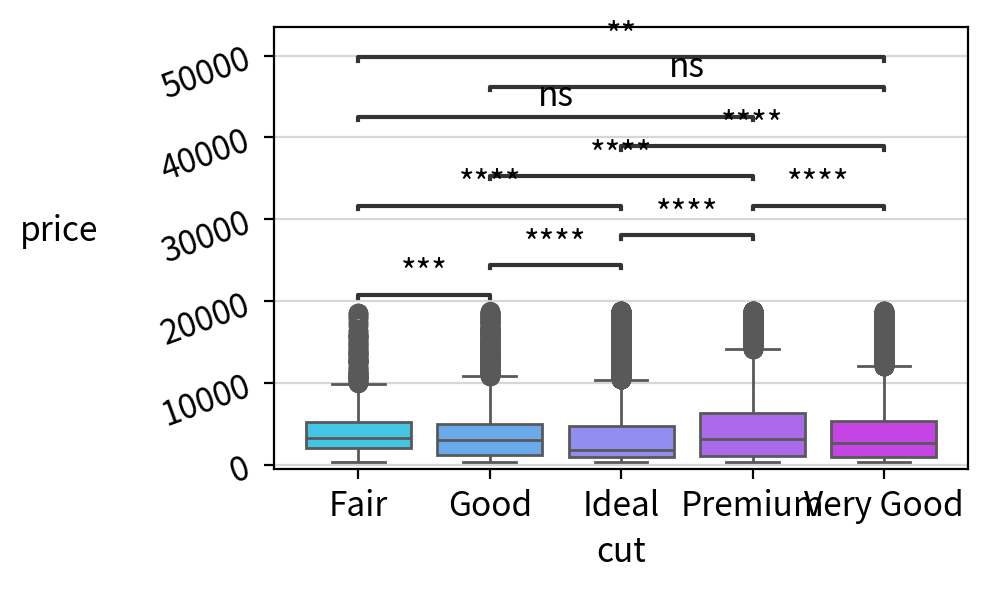

,검정방식,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,귀무가설 기각 여부,유의미한 차이 여부,효과 크기
0,Games Howell,Fair,Good,4341.954,3919.121,422.833,102.947,4.107,2803.307,0.000,0.116,True,True,거의 없음
1,Games Howell,Fair,Ideal,4341.954,3462.750,879.204,92.295,9.526,1883.080,0.000,0.232,True,True,작음
2,Games Howell,Fair,Premium,4341.954,4583.502,-241.548,96.009,-2.516,2198.298,0.087,-0.057,False,False,거의 없음
3,Games Howell,Fair,Very Good,4341.954,3981.016,360.938,95.527,3.778,2154.562,0.002,0.093,True,True,거의 없음
4,Games Howell,Good,Ideal,3919.121,3462.750,456.371,58.577,7.791,7480.705,0.000,0.121,True,True,거의 없음
5,Games Howell,Good,Premium,3919.121,4583.502,-664.381,64.270,-10.337,10094.516,0.000,-0.159,True,True,거의 없음
6,Games Howell,Good,Very Good,3919.121,3981.016,-61.895,63.547,-0.974,9655.235,0.867,-0.016,False,False,거의 없음
7,Games Howell,Ideal,Premium,3462.750,4583.502,-1120.752,45.288,-24.747,26487.259,0.000,-0.278,True,True,작음
8,Games Howell,Ideal,Very Good,3462.750,3981.016,-518.266,44.257,-11.710,24339.407,0.000,-0.134,True,True,거의 없음
9,Games Howell,Premium,Very Good,4583.502,3981.016,602.486,51.556,11.686,25791.196,0.000,0.145,True,True,거의 없음


#### color -> price

,검정방식,Source,ddof1,ddof2,F,p_unc,np2,효과크기
0,Welch ANOVA,color,6,18269.969,277.652,0.000,0.031,작음


y축 세우기 (단일 플롯)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

D vs. E: Custom statistical test, P_val:5.569e-01
E vs. F: Custom statistical test, P_val:1.476e-11
F vs. G: Custom statistical test, P_val:9.515e-06
G vs. H: Custom statistical test, P_val:0.000e+00
H vs. I: Custom statistical test, P_val:0.000e+00
I vs. J: Custom statistical test, P_val:2.349e-01
D vs. F: Custom statistical test, P_val:3.629e-12
E vs. G: Custom statistical test, P_val:7.376e-12
F vs. H: Custom statistical test, P_val:0.000e+00
G vs. I: Custom statistical test, P_val:1.783e-12
H vs. J: Custom statistical test, P_val:2.181e-12
D vs. G: Custom statistical test, P_val:1.049e-11
E vs. H: Custom statistical test, P_val:4.402e-12
F vs. I: Custom statistical test, P_val:2.890e-12
G vs. J: Custom statistical test, P_val:0.000e+00
D vs. H: Custom statistical test, P_val:1.2

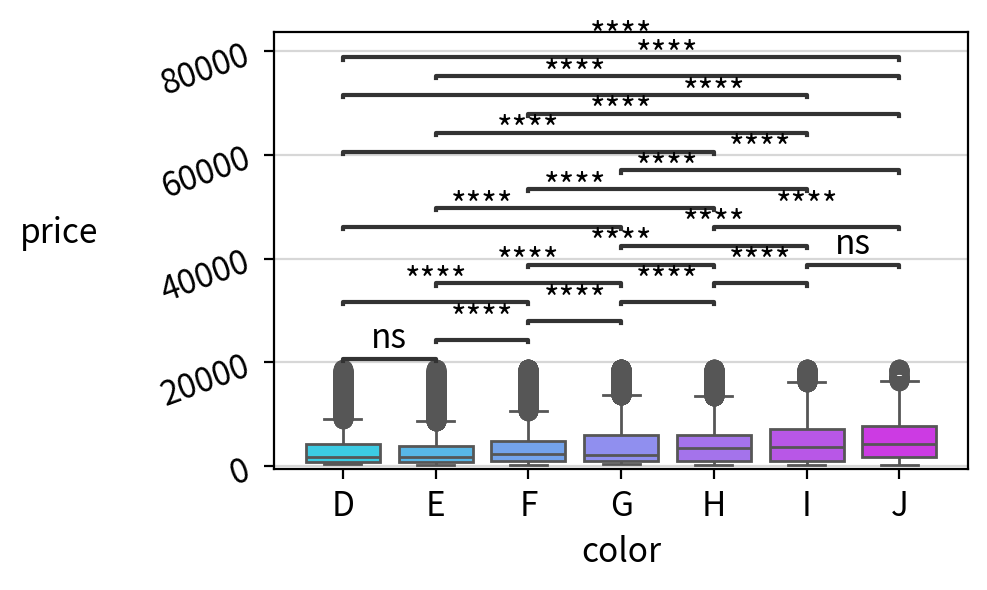

,검정방식,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,귀무가설 기각 여부,유의미한 차이 여부,효과 크기
0,Games Howell,D,E,3174.441,3079.608,94.833,53.068,1.787,14486.665,0.557,0.028,False,False,거의 없음
1,Games Howell,D,F,3174.441,3726.750,-552.309,56.362,-9.799,15489.025,0.000,-0.153,True,True,거의 없음
2,Games Howell,D,G,3174.441,4001.352,-826.911,55.929,-14.785,16257.654,0.000,-0.217,True,True,작음
3,Games Howell,D,H,3174.441,4482.855,-1308.414,61.760,-21.186,15016.920,0.000,-0.340,True,True,작음
4,Games Howell,D,I,3174.441,5081.751,-1907.310,76.067,-25.074,9440.484,0.000,-0.474,True,True,작음
5,Games Howell,D,J,3174.441,5326.415,-2151.974,93.200,-23.090,4195.115,0.000,-0.581,True,True,중간
6,Games Howell,E,F,3079.608,3726.750,-647.142,51.495,-12.567,18873.967,0.000,-0.181,True,True,거의 없음
7,Games Howell,E,G,3079.608,4001.352,-921.744,51.021,-18.066,20985.115,0.000,-0.246,True,True,작음
8,Games Howell,E,H,3079.608,4482.855,-1403.247,57.353,-24.467,15683.693,0.000,-0.372,True,True,작음
9,Games Howell,E,I,3079.608,5081.751,-2002.143,72.534,-27.603,8471.695,0.000,-0.515,True,True,중간


#### clarity -> price

,검정방식,Source,ddof1,ddof2,F,p_unc,np2,효과크기
0,Welch ANOVA,clarity,7,8541.969,221.943,0.000,0.027,작음


y축 세우기 (단일 플롯)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

I1 vs. IF: Custom statistical test, P_val:2.365e-12
IF vs. SI1: Custom statistical test, P_val:0.000e+00
SI1 vs. SI2: Custom statistical test, P_val:6.604e-12
SI2 vs. VS1: Custom statistical test, P_val:1.388e-11
VS1 vs. VS2: Custom statistical test, P_val:8.092e-01
VS2 vs. VVS1: Custom statistical test, P_val:3.727e-13
VVS1 vs. VVS2: Custom statistical test, P_val:0.000e+00
I1 vs. SI1: Custom statistical test, P_val:9.981e-01
IF vs. SI2: Custom statistical test, P_val:0.000e+00
SI1 vs. VS1: Custom statistical test, P_val:9.885e-02
SI2 vs. VS2: Custom statistical test, P_val:0.000e+00
VS1 vs. VVS1: Custom statistical test, P_val:0.000e+00
VS2 vs. VVS2: Custom statistical test, P_val:0.000e+00
I1 vs. SI2: Custom statistical test, P_val:0.000e+00
IF vs. VS1: Custom statistical test, P

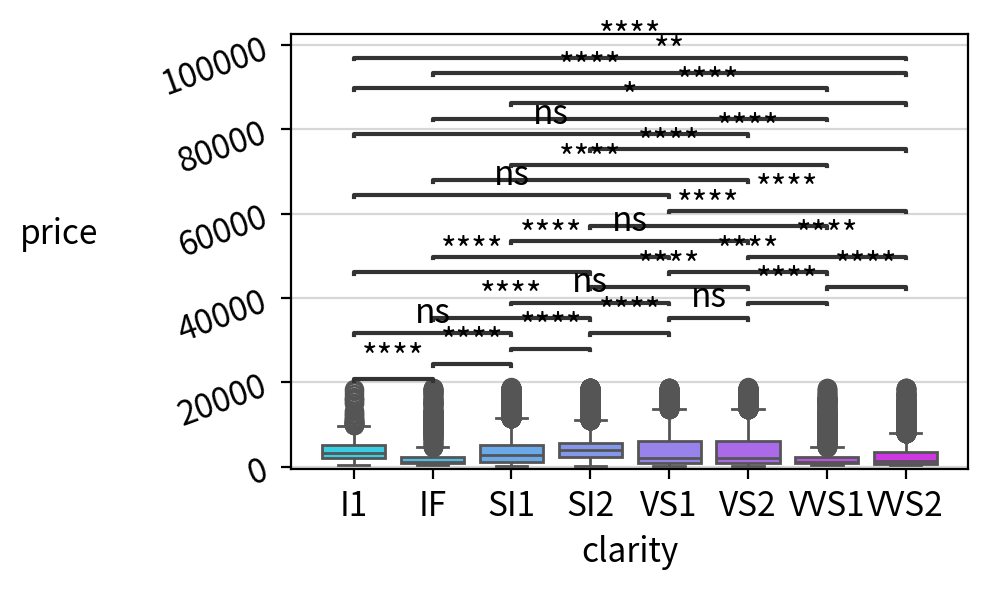

,검정방식,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,귀무가설 기각 여부,유의미한 차이 여부,효과 크기
0,Games Howell,I1,IF,3925.276,2870.570,1054.706,138.914,7.593,1903.846,0.000,0.290,True,True,작음
1,Games Howell,I1,SI1,3925.276,3996.165,-70.889,108.475,-0.654,900.022,0.998,-0.019,False,False,거의 없음
2,Games Howell,I1,SI2,3925.276,5057.455,-1132.180,112.419,-10.071,1035.965,0.000,-0.272,True,True,작음
3,Games Howell,I1,VS1,3925.276,3841.611,83.664,112.392,0.744,1034.654,0.996,0.021,False,False,거의 없음
4,Games Howell,I1,VS2,3925.276,3927.742,-2.466,109.522,-0.023,934.950,1.000,-0.001,False,False,거의 없음
5,Games Howell,I1,VVS1,3925.276,2526.603,1398.673,117.105,11.944,1203.205,0.000,0.430,True,True,작음
6,Games Howell,I1,VVS2,3925.276,3286.532,638.743,116.406,5.487,1181.572,0.000,0.172,True,True,거의 없음
7,Games Howell,IF,SI1,2870.570,3996.165,-1125.596,98.720,-11.402,2264.512,0.000,-0.295,True,True,작음
8,Games Howell,IF,SI2,2870.570,5057.455,-2186.886,103.037,-21.224,2666.208,0.000,-0.520,True,True,중간
9,Games Howell,IF,VS1,2870.570,3841.611,-971.042,103.008,-9.427,2660.104,0.000,-0.243,True,True,작음


In [24]:
# 여러 개 고유 값 분석 (ANOVA)

아노바_결과확인 , 아노바_사후결과확인 = my_EDA.여러_개의_고유값_분석(카테고리_변환 , 종속변수 , 가로 = 510 , 세로 = 310 , palette = 'cool')

In [25]:
아노바_결과확인

,독립변수,종속변수,집단 차이 여부,p_unc,효과크기
0,cut,price,True,0.000,작음
1,color,price,True,0.000,작음
2,clarity,price,True,0.000,작음


In [26]:
(
    아노바_사후결과확인.assign(abs_hedges=아노바_사후결과확인['hedges'].abs())
    .sort_values(by='abs_hedges', ascending=False)
    .drop(columns=['abs_hedges'])
)

# hedges 의 절대값을 가져와서 효과 크기 기준으로 정렬

,독립변수,종속변수,A,B,유의미한 차이 여부,hedges,효과 크기
42,clarity,price,SI2,VVS1,True,0.630,중간
17,color,price,E,J,True,-0.621,중간
12,color,price,D,J,True,-0.581,중간
32,clarity,price,IF,SI2,True,-0.520,중간
16,color,price,E,I,True,-0.515,중간
11,color,price,D,I,True,-0.474,작음
43,clarity,price,SI2,VVS2,True,0.431,작음
29,clarity,price,I1,VVS1,True,0.430,작음
21,color,price,F,J,True,-0.406,작음
38,clarity,price,SI1,VVS1,True,0.397,작음


In [27]:
# 교차 분석

# 적합도_검정결과 , 카이제곱_결과 , 비율부분_결과 = my_EDA.카이제곱_교차분석(카테고리_변환 , 종속변수 , 가로 = 500 , 세로 = 300 , 표시옵션 = 1)

my_EDA.카이제곱_교차분석(카테고리_변환 , 종속변수 , 가로 = 500 , 세로 = 300 , 표시옵션 = 1)                          

종속변수가 명목형 변수가 아니기 때문에 카이제곱 교차분석 생략!!


In [28]:
다중상관분석_결과 , 신호감지결과 = my_EDA.다중공산성_탐지(카테고리_변환 , 연속형_변수)

display(신호감지결과)

# carat 과 x , y , z 가 서로 상관계수가 너무 강함
# 필요에 따라 이들 중 몇 개는 지워야 함

,carat,x,y,z,depth,table
carat,1.000,0.996,0.996,0.993,0.030,0.194
x,0.996,1.000,0.998,0.987,-0.023,0.202
y,0.996,0.998,1.000,0.987,-0.025,0.195
z,0.993,0.987,0.987,1.000,0.104,0.159
depth,0.030,-0.023,-0.025,0.104,1.000,-0.245
table,0.194,0.202,0.195,0.159,-0.245,1.000


검정방법  상관계수    p값   강도결과  유의미한 차이 여부  X 정규성  Y 정규성  선형 여부  \
x     y                                                                        
carat x  스피어만 (Spearman) 0.996 0.000  많이 강함        True  False  False  False   
      y  스피어만 (Spearman) 0.996 0.000  많이 강함        True  False  False  False   
      z  스피어만 (Spearman) 0.993 0.000  많이 강함        True  False  False  False   
x     y  스피어만 (Spearman) 0.998 0.000  많이 강함        True  False  False  False   
      z  스피어만 (Spearman) 0.987 0.000  많이 강함        True  False  False  False   
y     z  스피어만 (Spearman) 0.987 0.000  많이 강함        True  False  False  False   

         이상치 여부  왜도 여부  
x     y                 
carat x   False   True  
      y   False   True  
      z   False   True  
x     y   False   True  
      z   False   True  
y     z   False   True

,최대 y,최대 상관계수,개수,columns,진단결과
x,,,,,
x,y,0.998,3,"y , carat , z",다중공선성 의심
y,x,0.998,3,"x , carat , z",다중공선성 의심
carat,x,0.996,3,"x , y , z",다중공선성 의심
z,carat,0.993,3,"carat , x , y",다중공선성 의심
depth,table,-0.245,0,-,양호
table,depth,-0.245,0,-,양호


In [29]:
my_stats.VIF계산하기(카테고리_변환)

,const,carat,x,y,z,depth,table,price
0,1.000,0.230,3.950,3.980,2.430,61.500,55.000,326
1,1.000,0.210,3.890,3.840,2.310,59.800,61.000,326
2,1.000,0.230,4.050,4.070,2.310,56.900,65.000,327
3,1.000,0.290,4.200,4.230,2.630,62.400,58.000,334
4,1.000,0.310,4.340,4.350,2.750,63.300,58.000,335


8

,VIF
x,57.259
carat,33.438
z,23.426
y,20.370
price,7.109
depth,1.534
table,1.168
